In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi':        110,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.size':         12,
})

train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')
print(f'Train: {train.shape} | Test: {test.shape}')

Train: (1460, 81) | Test: (1459, 80)


In [4]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Train columns: {train.columns.tolist()}\n")
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)
Train columns: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'En

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## 1. Целевая переменная — SalePrice

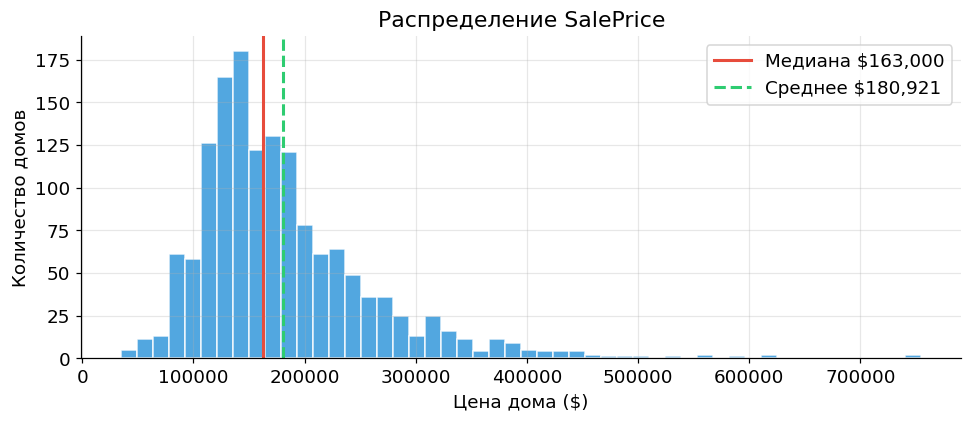

In [2]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train['SalePrice'], bins=50, color='#3498db', alpha=0.85, edgecolor='white')
ax.axvline(train['SalePrice'].median(), color='#e74c3c', lw=2, label=f'Медиана ${train["SalePrice"].median():,.0f}')
ax.axvline(train['SalePrice'].mean(),   color='#2ecc71', lw=2, linestyle='--', label=f'Среднее ${train["SalePrice"].mean():,.0f}')
ax.set_xlabel('Цена дома ($)')
ax.set_ylabel('Количество домов')
ax.set_title('Распределение SalePrice')
ax.legend()
plt.tight_layout()
plt.show()
# Среднее > медианы → правый скос → нужна log-трансформация

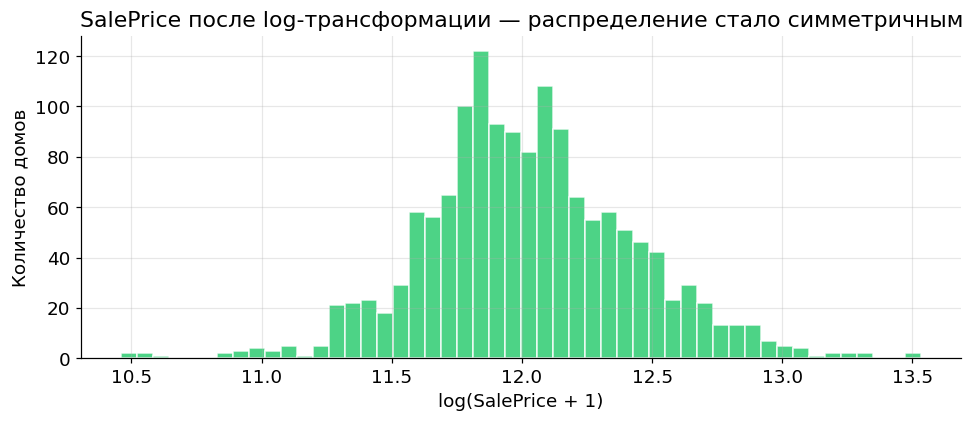

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log1p(train['SalePrice']), bins=50, color='#2ecc71', alpha=0.85, edgecolor='white')
ax.set_xlabel('log(SalePrice + 1)')
ax.set_ylabel('Количество домов')
ax.set_title('SalePrice после log-трансформации — распределение стало симметричным')
plt.tight_layout()
plt.show()

## 2. Пропуски

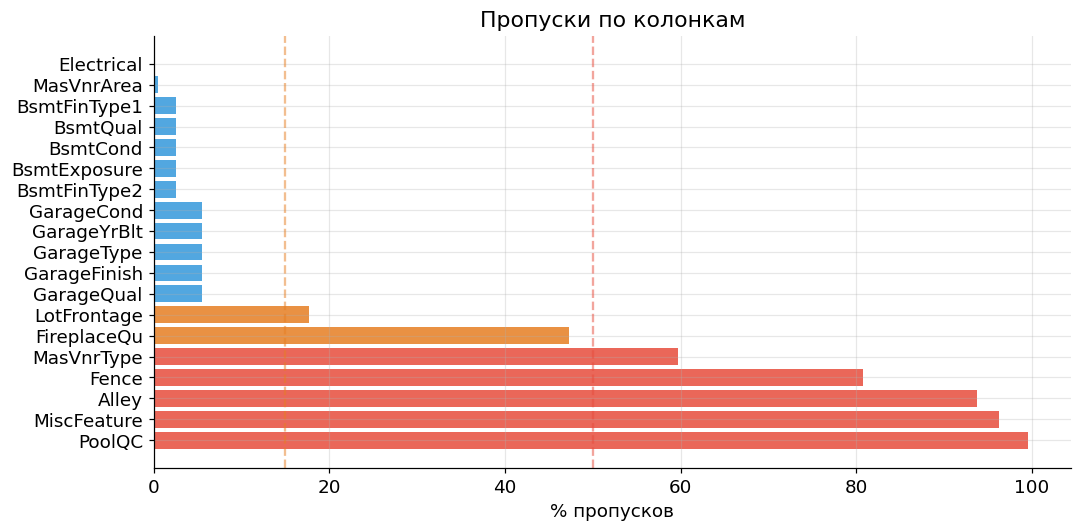

In [6]:
nulls = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
nulls = nulls[nulls > 0]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if x > 50 else '#e67e22' if x > 15 else '#3498db' for x in nulls.values]
ax.barh(nulls.index, nulls.values, color=colors, alpha=0.85)
ax.axvline(50, color='#e74c3c', lw=1.5, linestyle='--', alpha=0.5)
ax.axvline(15, color='#e67e22', lw=1.5, linestyle='--', alpha=0.5)
ax.set_xlabel('% пропусков')
ax.set_title('Пропуски по колонкам')
plt.tight_layout()
plt.show()
# Красный >50%: PoolQC, MiscFeature, Alley, Fence — NA = нет объекта
# Синий <15%: реальные пропуски, заполняем медианой/модой

## 3. Топ признаков по корреляции с ценой

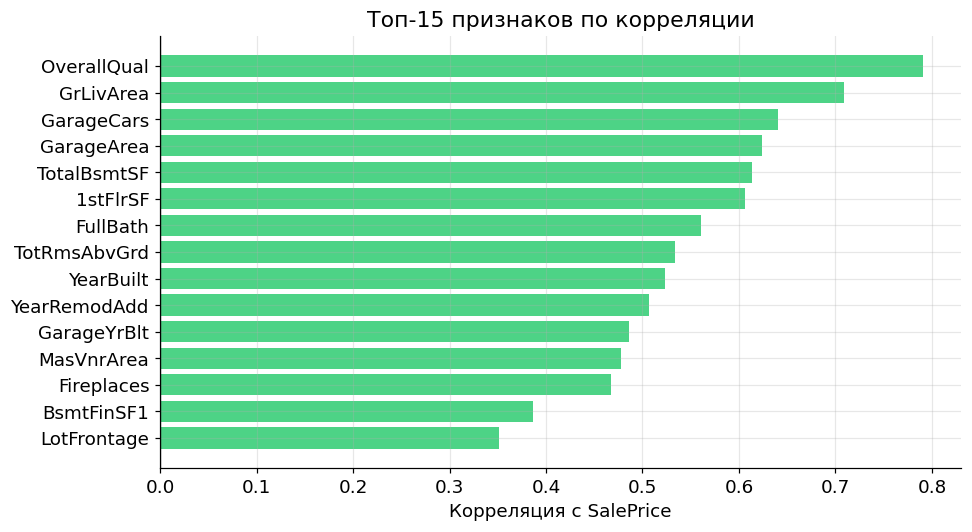

In [7]:
corr = train.select_dtypes(include=np.number).corr()['SalePrice'].drop('SalePrice')
top  = corr.abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71' if corr[i] > 0 else '#e74c3c' for i in top.index]
ax.barh(top.index[::-1], corr[top.index[::-1]].values, color=colors[::-1], alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Корреляция с SalePrice')
ax.set_title('Топ-15 признаков по корреляции')
plt.tight_layout()
plt.show()

## 4. Главный признак — OverallQual

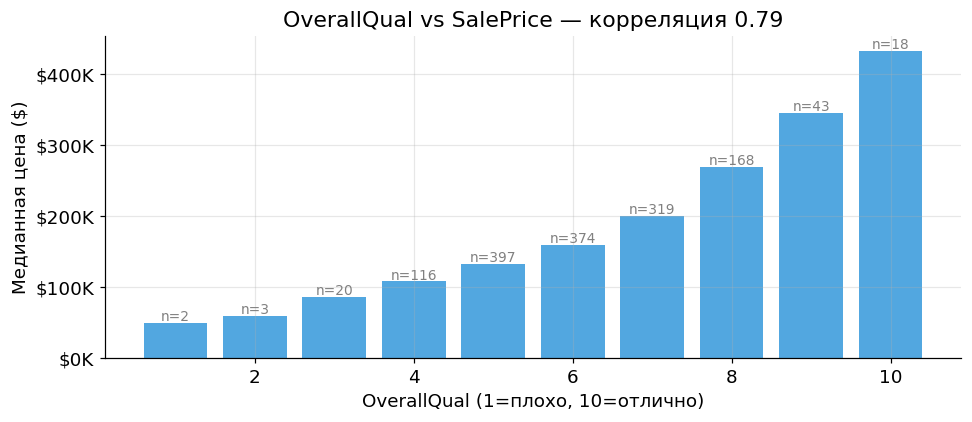

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
medians = train.groupby('OverallQual')['SalePrice'].median()
counts  = train.groupby('OverallQual')['SalePrice'].count()
bars = ax.bar(medians.index, medians.values, color='#3498db', alpha=0.85)
for bar, (q, n) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'n={n}', ha='center', fontsize=9, color='gray')
ax.set_xlabel('OverallQual (1=плохо, 10=отлично)')
ax.set_ylabel('Медианная цена ($)')
ax.set_title('OverallQual vs SalePrice — корреляция 0.79')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

## 5. Площадь vs Цена

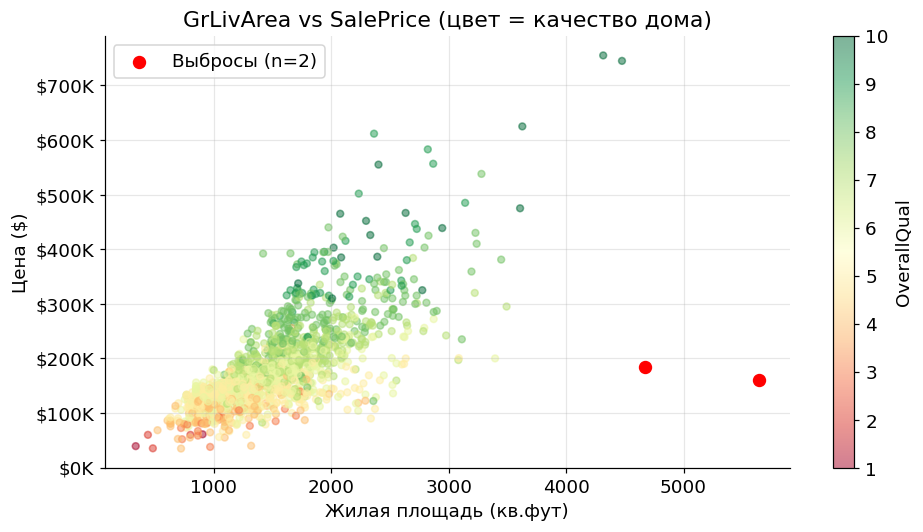

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    train['GrLivArea'], train['SalePrice'],
    c=train['OverallQual'], cmap='RdYlGn',
    alpha=0.5, s=20
)
plt.colorbar(sc, ax=ax, label='OverallQual')

# Выбросы — дорогая земля, маленький дом
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'],
           color='red', s=60, zorder=5, label=f'Выбросы (n={len(outliers)})')

ax.set_xlabel('Жилая площадь (кв.фут)')
ax.set_ylabel('Цена ($)')
ax.set_title('GrLivArea vs SalePrice (цвет = качество дома)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()
plt.tight_layout()
plt.show()
# Два красных выброса внизу справа — большие дома за низкую цену
# Возможно продажи между родственниками. Стоит удалить перед обучением.

## 6. Год постройки vs Цена

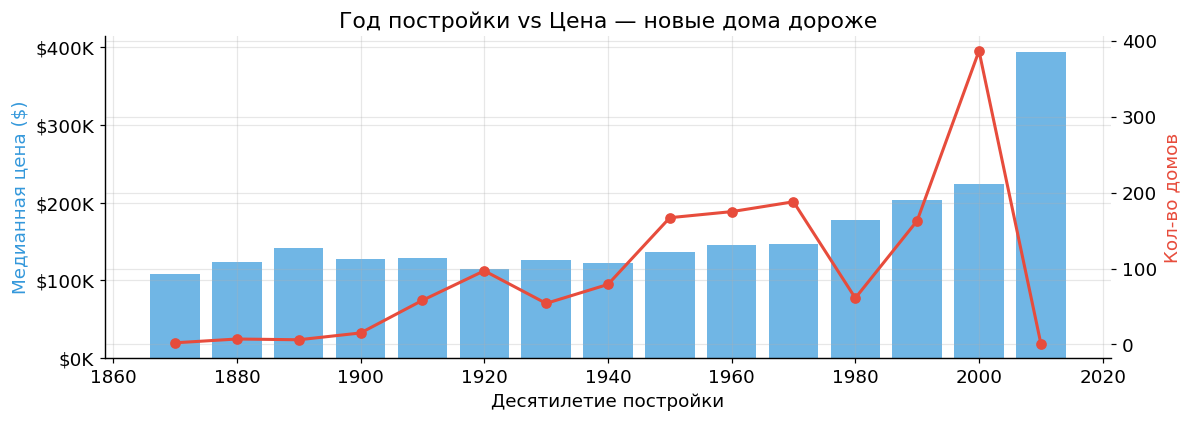

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
decade = (train['YearBuilt'] // 10) * 10
decade_med = train.groupby(decade)['SalePrice'].median()
decade_cnt = train.groupby(decade)['SalePrice'].count()

ax2 = ax.twinx()
ax.bar(decade_med.index, decade_med.values, width=8, color='#3498db', alpha=0.7)
ax2.plot(decade_med.index, decade_cnt.values, 'o-', color='#e74c3c', lw=2)

ax.set_xlabel('Десятилетие постройки')
ax.set_ylabel('Медианная цена ($)', color='#3498db')
ax2.set_ylabel('Кол-во домов', color='#e74c3c')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Год постройки vs Цена — новые дома дороже')
plt.tight_layout()
plt.show()

## 7. Район (Neighborhood) vs Цена

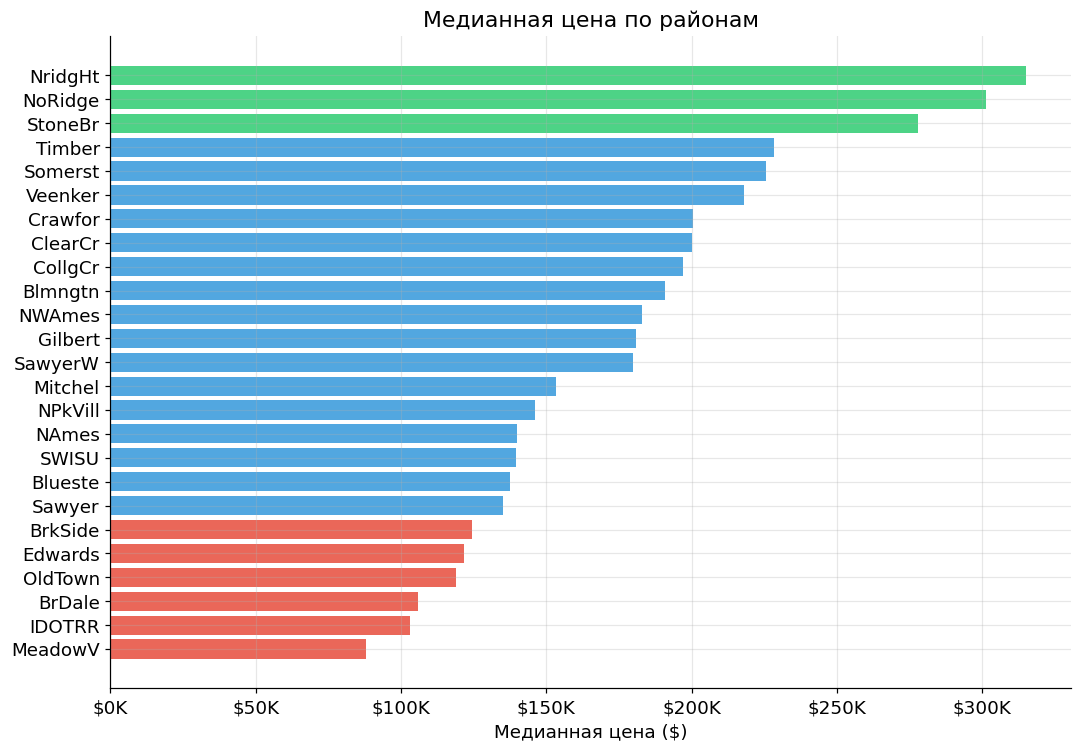

In [11]:
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=True).index

fig, ax = plt.subplots(figsize=(10, 7))
medians = train.groupby('Neighborhood')['SalePrice'].median().loc[order]
colors  = ['#e74c3c' if v < 130000 else '#2ecc71' if v > 250000 else '#3498db'
           for v in medians.values]
ax.barh(order, medians.values, color=colors, alpha=0.85)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_xlabel('Медианная цена ($)')
ax.set_title('Медианная цена по районам')
plt.tight_layout()
plt.show()

## 8. Матрица корреляций топ признаков

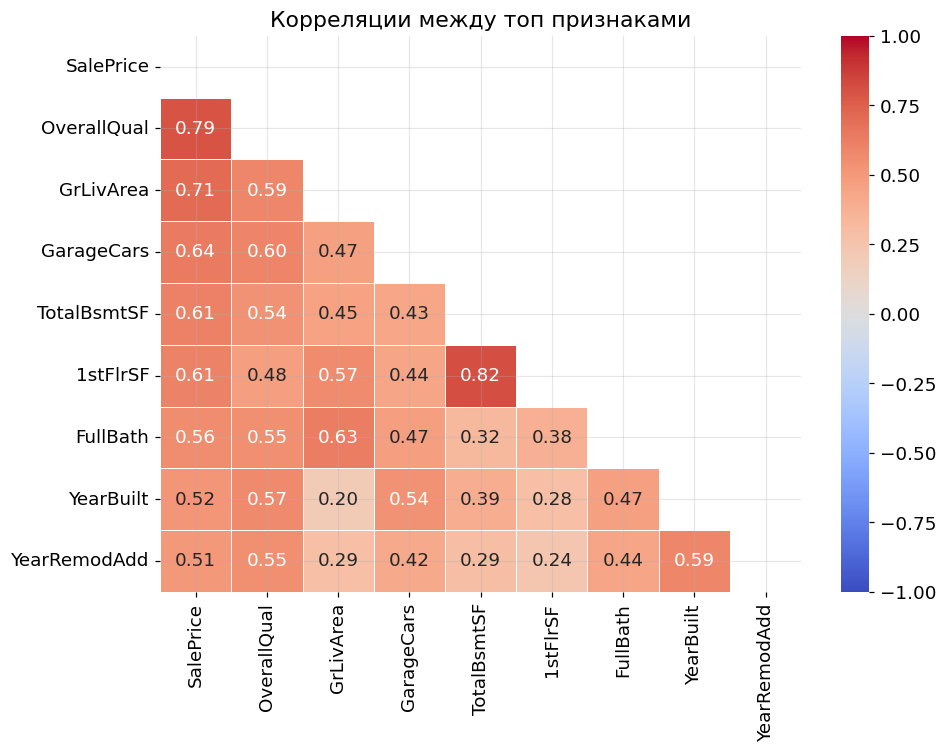

In [12]:
top_cols = ['SalePrice','OverallQual','GrLivArea','GarageCars',
            'TotalBsmtSF','1stFlrSF','FullBath','YearBuilt','YearRemodAdd']

corr_matrix = train[top_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Корреляции между топ признаками')
plt.tight_layout()
plt.show()

## 9. Ванные, гараж, подвал — дискретные признаки

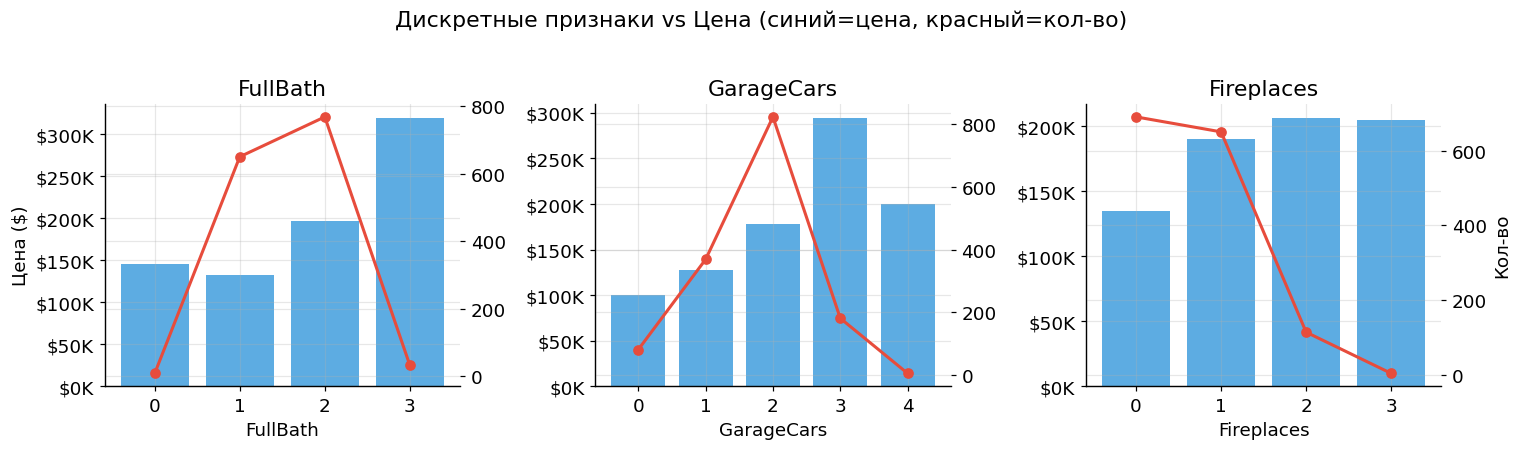

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['FullBath', 'GarageCars', 'Fireplaces']):
    med = train.groupby(col)['SalePrice'].median()
    cnt = train.groupby(col)['SalePrice'].count()
    ax2 = ax.twinx()
    ax.bar(med.index.astype(str), med.values, color='#3498db', alpha=0.8)
    ax2.plot(range(len(med)), cnt.values, 'o-', color='#e74c3c', lw=2)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.set_ylabel('Цена ($)' if ax == axes[0] else '')
    ax2.set_ylabel('Кол-во' if ax == axes[-1] else '')

plt.suptitle('Дискретные признаки vs Цена (синий=цена, красный=кол-во)', y=1.02)
plt.tight_layout()
plt.show()

## 10. Выбросы

In [14]:
# Большие дома за маленькие деньги — аномалия
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
print('Выбросы (большая площадь, низкая цена):')
print(outliers[['GrLivArea','SalePrice','OverallQual','SaleCondition','Neighborhood']].to_string())
print()
print('SaleCondition у выбросов:', outliers['SaleCondition'].values)
print('Вывод: Partial/Abnorml — нерыночные продажи. Лучше удалить из train.')

Выбросы (большая площадь, низкая цена):
      GrLivArea  SalePrice  OverallQual SaleCondition Neighborhood
523        4676     184750           10       Partial      Edwards
1298       5642     160000           10       Partial      Edwards

SaleCondition у выбросов: <StringArray>
['Partial', 'Partial']
Length: 2, dtype: str
Вывод: Partial/Abnorml — нерыночные продажи. Лучше удалить из train.


In [16]:
print('''
ИТОГИ EDA
=========

TARGET:
  SalePrice имеет правый скос → обязательна log-трансформация
  Диапазон: $34K — $755K, медиана $163K

ТОП ПРИЗНАКИ:
  OverallQual  (r=0.79) — качество дома, самый сильный сигнал
  GrLivArea    (r=0.71) — жилая площадь
  GarageCars   (r=0.64) — размер гаража
  YearBuilt    (r=0.52) — год постройки

ПРОПУСКИ:
  PoolQC, MiscFeature, Alley, Fence, FireplaceQu  → NA = нет объекта → 'None'
  LotFrontage (18%)  → медиана по Neighborhood
  GarageYrBlt (6%)   → заполнить YearBuilt
  Electrical  (0.1%) → мода

ВЫБРОСЫ:
  2 дома: GrLivArea > 4000 и SalePrice < 300K → удалить из train

FEATURE ENGINEERING (план):
  TotalSF     = TotalBsmtSF + 1stFlrSF + 2ndFlrSF
  HouseAge    = YrSold - YearBuilt
  TotalBath   = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
  QualArea    = OverallQual * GrLivArea
''')


ИТОГИ EDA

TARGET:
  SalePrice имеет правый скос → обязательна log-трансформация
  Диапазон: $34K — $755K, медиана $163K

ТОП ПРИЗНАКИ:
  OverallQual  (r=0.79) — качество дома, самый сильный сигнал
  GrLivArea    (r=0.71) — жилая площадь
  GarageCars   (r=0.64) — размер гаража
  YearBuilt    (r=0.52) — год постройки

ПРОПУСКИ:
  PoolQC, MiscFeature, Alley, Fence, FireplaceQu  → NA = нет объекта → 'None'
  LotFrontage (18%)  → медиана по Neighborhood
  GarageYrBlt (6%)   → заполнить YearBuilt
  Electrical  (0.1%) → мода

ВЫБРОСЫ:
  2 дома: GrLivArea > 4000 и SalePrice < 300K → удалить из train

FEATURE ENGINEERING (план):
  TotalSF     = TotalBsmtSF + 1stFlrSF + 2ndFlrSF
  HouseAge    = YrSold - YearBuilt
  TotalBath   = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
  QualArea    = OverallQual * GrLivArea

